# 15. Ensemble Methods

:::{admonition} Course Website 
http://54.243.252.9/ce-5319-webroot/ 
:::

## Readings

## Videos

## Background
Ensemble methods arose in part from solution stacking in geophysics, where noisy seismic returns were averaged after time-shifting to align true signals. This principle — combining uncertain views to amplify signal — also underlies synthetic aperture radar, where many low-resolution snapshots create a composite with much finer resolution.

In the same spirit, ensemble machine learning combines predictions from multiple models. The models may be weak learners (like decision stumps in boosting), strong learners trained on different data subsets (as in bagging), or heterogeneous models blended intelligently (as in stacking). Ensemble methods tend to produce more accurate, stable, and reliable predictions than any individual model alone — especially in complex, data-limited domains like civil and environmental systems.

## Definition of an Ensemble 
>**Classical Context**
In classical statistics and time series analysis, an ensemble refers to a conceptual collection of possible realizations or sample paths of a stochastic process at a fixed point in time. Each member of the ensemble represents a possible state or trajectory that the system could be in, even if we only observe one in practice.
>
>This perspective allows us to distinguish between two forms of averaging:
>
>Ensemble average: Mean over many realizations at a single time.
>
>Time average: Mean over time from a single realization.
>
>In practical terms, especially in signal processing and geophysical contexts, an ensemble may consist of a set of short-duration signals or observations taken from many similar systems (or repeated trials) — each considered a member of a larger, unobservable process that extends indefinitely before and after the observation window. The ensemble framework helps account for uncertainty, nonstationarity, and the inherently partial nature of real-world data collection.

>**Metaphorical - Time Series Context**
Imagine standing at a window looking out at a river — you can only see a small section at a time. The water that has already flowed past is out of view, and the water upstream hasn't arrived yet. But you're not the only person with a window. Along the river, others are watching their own small sections too.
>
>Each of those views — short, limited glimpses of a much longer river — is like a member of an ensemble. No one sees the entire flow, but by comparing many windows at once, we can better understand the character of the whole river.
>
>In time series or classical statistics, an ensemble is just like this: a collection of snapshots from different realizations of a process we believe is governed by the same underlying rules. We use these slices to estimate properties of the full system — even if we never get to see its beginning or end.
>

![](Ensemble.png)

Machine learning borrows these ideas from classical statistics and time series. Instead of observing different realizations of a natural process, ML ensembles combine the predictions of multiple models — each one trained on different views of the same data. Just as classical ensembles help us estimate the hidden structure of a system from partial glimpses, ML ensembles aim to improve prediction accuracy by averaging or combining the perspectives of diverse models. Each model contributes a unique “window” into the data, and by blending them, we can reduce noise, correct individual biases, and make more robust decisions.

The left panel in the figure above shows: averaging over signals (a classical ensemble)
- Multiple noisy observations of the same underlying process (e.g., seismic traces, sensor readings).
- Averaging them recovers the true signal.
- Classic interpretation in geophysics and time series analysis.

The right panel in the figure above shows: averaging over predictions (a ML ensemble)
- Different models (linear regression and a shallow decision tree) fit to noisy data.
- Their predictions are averaged to form an ensemble output.
- This illustrates how blending models can yield better generalization than relying on any one model alone.

## Motivation and Background
- Real-world models are noisy, biased, or underfit.
- Using multiple models can improve robustness and predictive accuracy.

Analogy to geophysical signal stacking:
- In seismic processing, solution stacking combines noisy signals aligned on a common event (e.g., reflection arrival).
- Like synthetic aperture radar (SAR), ensemble methods improve resolution and fidelity using multiple partial views.
- The idea: many weak inputs → strong consensus.

### What Are Ensemble Methods?
General definition: Combine multiple learning models to produce better results than any single model alone.

Types of ensemble diversity:

- Same model + different data subsets (e.g., bagging)
- Different models + same data (e.g., stacking)
- Sequential correction (e.g., boosting)

### Common Ensemble Techniques
|Method|	Key Idea	|Main Benefit|
|------|----------------|------------|
|Bagging	|Build models on bootstrapped data	|Reduces variance|
|Boosting	|Sequentially correct prior errors	|Reduces bias|
|Stacking	|Combine predictions from different models	|Flexibility, performance|

#### Bagging (Bootstrap Aggregating):

- Used in Random Forests

- Improves stability and reduces overfitting

#### Boosting:

- Models focus on data points previously mispredicted

- Includes AdaBoost, Gradient Boosting Machines

#### Stacking:

- Learns how to combine different model outputs

- Meta-model (e.g., linear regressor) learns the optimal blend

### Why Ensembles Work

Mathematical intuition: Combining low-bias, high-variance models reduces variance. Often outperform more complex single models.

Useful when:

- Data are noisy or sparse

- Models individually perform inconsistently

- No "best" model is obvious

### Applications in Civil & Environmental Engineering
- Hydrologic forecasting from multiple rainfall-runoff models
- Structural failure prediction from different feature sets
- Water demand forecasting using ensembles of time series models
- Groundwater contamination risk prediction from heterogeneous sources

### Limitations and Considerations
- Computational cost (multiple models)
- Interpretability may decrease
- Risk of redundancy if all models are too similar (colinearity in regression is a related issue)

### Suggested Assignments (For Future Use)
- Visual: Compare individual vs ensemble predictions on toy datasets
- Programming: Build and compare a simple bagged ensemble in sklearn
- Reflection: “What features in civil systems would benefit most from combining multiple perspectives?”

## Example (Using Synthetic Dataset)
The simulated dataset follows the form:

$$y=f(x) + \epsilon$$

The simulated/generated dataset is simply $y=f(x) + \epsilon$ where $f$ is a deterministic function (e.g., linear, quadratic, etc.), and the noise $\epsilon$ is drawn from a Gaussian distribution with mean $\mu =0$ and standard deviation $\sigma = \text{noise}$ as specified in the function call.

The script illustrates:
- Bagging – uses multiple decision trees on bootstrapped samples. It reduces variance and works well when the base estimator is high-variance (like decision trees).
- Boosting – uses gradient boosting to iteratively improve the model. It reduces bias by correcting mistakes sequentially.
- Stacking – combines a linear regressor and k-nearest neighbors, with a second linear regressor as the meta-model. This method blends very different model types and can be quite powerful, though often underappreciated. One tradeoff is that interpreting model blending can be difficult, and stacking is prone to overfitting if not managed carefully.

:::{tip}
The script provides enough of a framework (and syntax) to get you started — which is the main goal. However, in your own applications, be sure to consult the module documentation: [sklearn](https://scikit-learn.org/stable/).  The module landing page includes helpful examples and tutorials. Also, don’t overlook AI assistants — they’re designed to help you frame your scripts and can save you considerable time in getting started and debugging.
:::

:::{admonition} Lab/In Class Exploration(s)
This script is just a starting point. In class, we’ll modify the noise level, change the number of estimators, and explore different base models.
Try re-running this example using `make_classification()`instead of `make_regression`, and compare how ensemble classifiers like `RandomForestClassifier` and `AdaBoostClassifier` behave.
:::

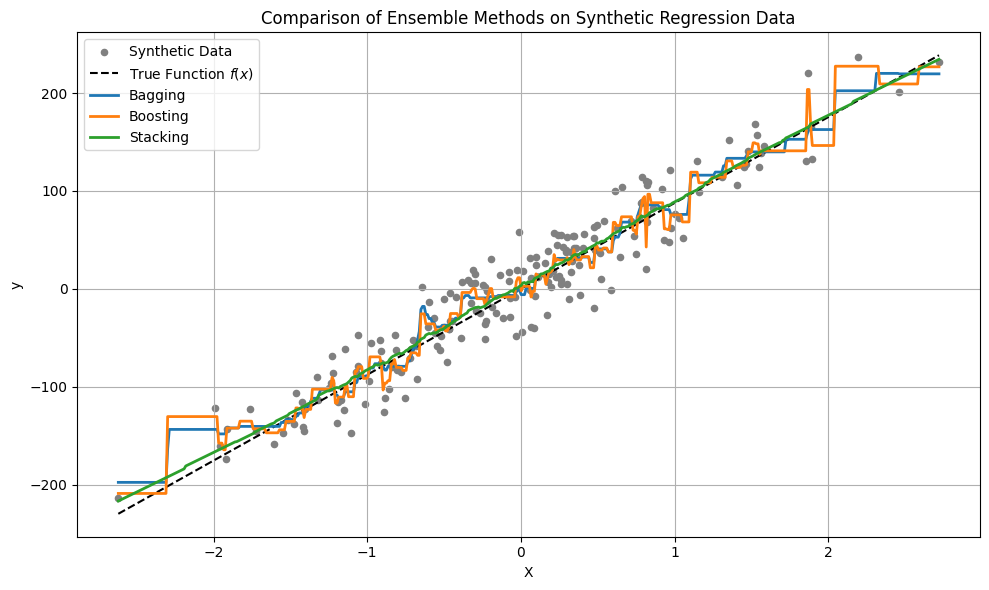

In [1]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

LinEAR = True
# === Generate Synthetic Data ===
#X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
if LinEAR:
    X, y, coef = make_regression(n_samples=200, n_features=1, noise=25, coef=True,random_state=42) # linear base function
    X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    y_true = X_plot.flatten() * coef  # since f(x) = x * coef
else:
    from sklearn.datasets import make_friedman1
    X, y = make_friedman1(n_samples=200, n_features=5, noise=25, random_state=42)

    # Create X_plot by varying feature 0, fixing others at their mean
    x0_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 500).reshape(-1, 1)
    X_fixed = np.mean(X[:, 1:], axis=0).reshape(1, -1).repeat(500, axis=0)
    X_plot = np.hstack([x0_vals, X_fixed])

    y_true = None  # Optional placeholder, since no known ground truth

# === Define Ensemble Models ===

# 1. Bagging (bootstrap aggregating)
bagging = BaggingRegressor(
#    base_estimator=DecisionTreeRegressor(max_depth=4),
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=10,
    random_state=42
)

# 2. Boosting (gradient boosting)
boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# 3. Stacking (combination of different models)
stacking = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('knn', KNeighborsRegressor(n_neighbors=5))
    ],
    final_estimator=LinearRegression()
)

# === Fit Models ===
bagging.fit(X, y)
boosting.fit(X, y)
stacking.fit(X, y)

# === Generate Predictions ===
y_bag = bagging.predict(X_plot)
y_boost = boosting.predict(X_plot)
y_stack = stacking.predict(X_plot)

if LinEAR:
# === Plot Results ===
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, s=20, color='gray', label='Synthetic Data')
    plt.plot(X_plot, y_true, color='black', linestyle='--', label='True Function $f(x)$')  # <- new line
    plt.plot(X_plot, y_bag, label='Bagging', linewidth=2)
    plt.plot(X_plot, y_boost, label='Boosting', linewidth=2)
    plt.plot(X_plot, y_stack, label='Stacking', linewidth=2)
    plt.title("Comparison of Ensemble Methods on Synthetic Regression Data")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
# === Plot Results ===
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], y, s=20, color='gray', label='Synthetic Data (Feature 0)')
    plt.plot(x0_vals, y_bag, label='Bagging Prediction', linewidth=2)
    plt.plot(x0_vals, y_boost, label='Boosting Prediction', linewidth=2)
    plt.plot(x0_vals, y_stack, label='Stacking Prediction', linewidth=2)
    plt.title("Ensemble Method Predictions on Feature 0 (Friedman1)")
    plt.xlabel("Feature 0")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Below is a standalone code cell that mirrors the structure of the regression example (above), but uses classification instead, with:

- `make_classification()` to generate labeled data

- `RandomForestClassifier`, `AdaBoostClassifier`, and `StackingClassifier`

- A decision boundary plot for visual comparison

Random Forest Accuracy: 0.978
AdaBoost Accuracy: 0.978
Stacking Accuracy: 0.978


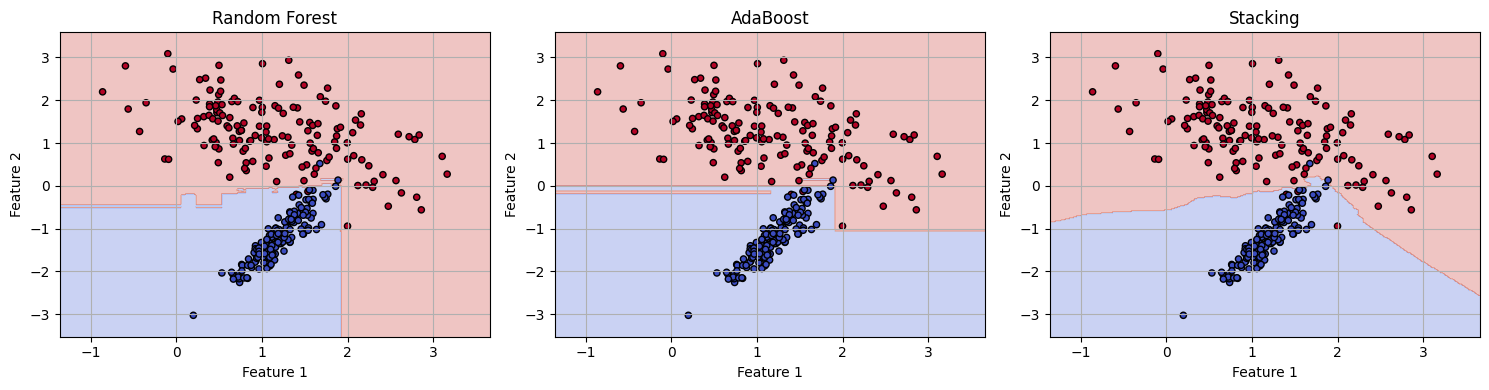

In [2]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# === Synthetic Classification Data ===
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

# === Split for simplicity (optional) ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Define Ensemble Classifiers ===

# 1. Bagging-style (Random Forest)
rf = RandomForestClassifier(n_estimators=50, random_state=42)

# 2. Boosting
boost = AdaBoostClassifier(n_estimators=50, random_state=42)

# 3. Stacking
stack = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression()), 
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    final_estimator=LogisticRegression()
)

# === Fit All Models ===
rf.fit(X_train, y_train)
boost.fit(X_train, y_train)
stack.fit(X_train, y_train)

# === Predict and Evaluate ===
models = {'Random Forest': rf, 'AdaBoost': boost, 'Stacking': stack}

for name, model in models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Accuracy: {acc:.3f}")

# === Plot Decision Boundaries ===
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items()):
    Z = model.predict(grid).reshape(xx.shape)
    plt.subplot(1, 3, i+1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, edgecolor='k')
    plt.title(name)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)

plt.tight_layout()
plt.show()
